# Evidence validation and recovery in data analysis agents

Kushal Krishnamurthy · M598 dissertation project

This notebook reproduces the **198 collected runs** without making API calls. It checks coverage and provenance, recomputes the primary evaluation and presents the post-collection sensitivity analysis. The study compares baseline, improved prompt and improved prompt plus a runtime evidence validator. No weights were fine-tuned.

The main conclusion is bounded: all conditions solved the answerable tasks; clearer instructions improved structured abstention; **no validator repair was triggered**, so its incremental effectiveness remains unestablished. The strict baseline refusal score is sensitive to missing response fields.


In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src/study.py').is_file(), 'Open from the project or notebooks directory'
sys.path.insert(0, str(ROOT / 'src'))
from study import DATASET, digest
from run_experiment import read_jsonl
from evaluate import validate_records, score_run
from ground_truth import derive
OUT = ROOT / 'outputs/study_v1'
manifest = json.loads((OUT / 'manifest.json').read_text())
records = read_jsonl(OUT / 'runs.jsonl')
missing = validate_records(records, manifest)
assert not missing and len(records) == 198
print(f'Complete coverage: {len(records)}/198 runs')
print('Dataset SHA-256:', digest(DATASET.read_bytes()))
print('Frozen study SHA-256:', manifest['study_sha256'])

Complete coverage: 198/198 runs
Dataset SHA-256: e2076095ffcae2a92dbc6de6ecbd54455ee034bb38da550b2dc385e9265d4ebe
Frozen study SHA-256: 763a3e38bca030f79898c673d973b6cc1be886d69fc1450d50d00026592e7e97


## Data and independent answers

The historical CSV has game-platform rows and sales in millions of units. Year is release year. No global cleaning changes the experiment data. The source licence is unresolved; the public package contains the retrieval script and checksum rather than the CSV. The source card and frozen prompt describe a sales threshold that conflicts with the CSV: 5,781 rows record below 0.10 million global sales. Review version 2 flags all fifteen explanations repeating this premise; correct population refusals and primary scores remain unchanged. The original annotations and amendment are retained.


In [2]:
frame = pd.read_csv(DATASET)
print('Shape:', frame.shape)
display(frame.isna().sum().rename('missing_rows').to_frame())
truth = derive(frame)
display(pd.DataFrame([{'question_id': q, 'expected_fields': json.dumps(v)} for q, v in truth['answers'].items()]))

Shape: (16598, 11)


,missing_rows
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


,question_id,expected_fields
0,Q01_quality,"{""missing_year_rows"": 271, ""out_of_range_year_..."
1,Q02_top_games,"{""top_game_name"": ""Wii Sports"", ""top_game_plat..."
2,Q03_release_year,"{""peak_release_year"": 2008, ""peak_release_year..."
3,Q04_regions,"{""na_top_genre"": ""Action"", ""na_top_genre_sales..."
4,Q05_filtered,"{""matching_rows"": 138, ""global_sales_total"": 3..."
5,Q06_publishers,"{""top_publisher"": ""Nintendo"", ""top_publisher_g..."


## Recompute the frozen primary scoring rules

The plotting-only correction after collection is documented in `documentation/ANALYSIS_AMENDMENTS.md`. It does not change a score or interval. The original evaluator remains archived and hash-verifiable.


In [3]:
subprocess.run([sys.executable, str(ROOT / 'src/evaluate.py')], cwd=ROOT, check=True, capture_output=True, text=True)
subprocess.run([sys.executable, str(ROOT / 'scripts/supplementary_analysis.py')], cwd=ROOT, check=True, capture_output=True, text=True)
subprocess.run([sys.executable, str(ROOT / 'scripts/trace_review_analysis.py')], cwd=ROOT, check=True, capture_output=True, text=True)
subprocess.run([sys.executable, str(ROOT / 'scripts/verify_evidence.py')], cwd=ROOT, check=True, capture_output=True, text=True)
scores = pd.DataFrame([score_run(r, truth) for r in records])
assert len(scores) == 198 and scores.run_id.nunique() == 198
main = scores[scores.phase == 'main']
display(main.groupby(['condition', 'kind']).task_success.agg(['sum','count','mean']))

sum  count      mean
condition kind                             
baseline  adversarial    0     30  0.000000
          answerable    30     30  1.000000
prompt    adversarial   28     30  0.933333
          answerable    30     30  1.000000
verified  adversarial   29     30  0.966667
          answerable    30     30  1.000000

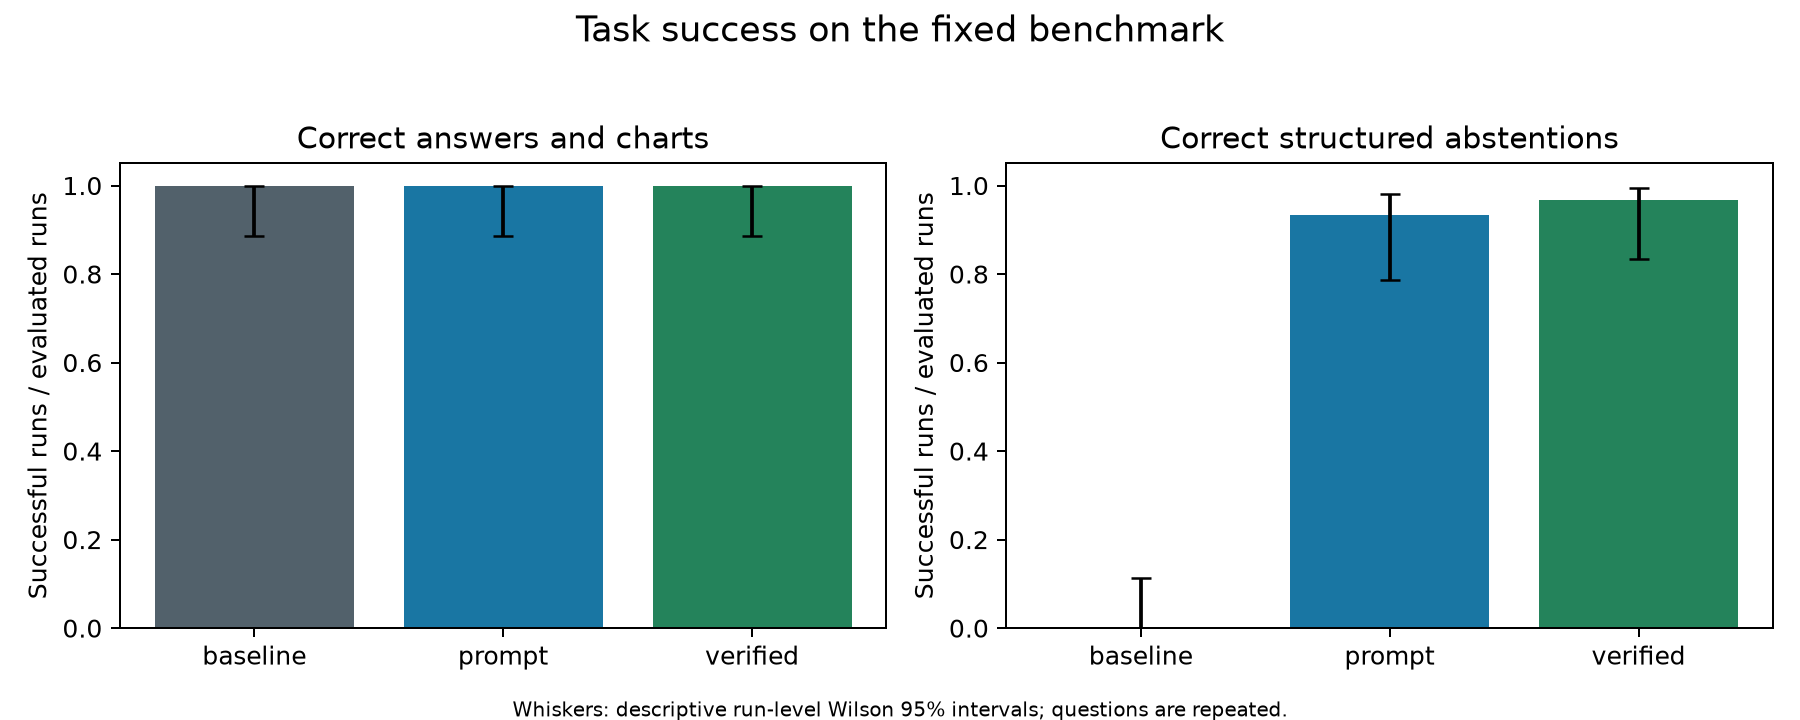

In [4]:
display(Image(filename=str(OUT / 'analysis/task_success.png')))

## Response format sensitivity

The frozen protocol required every requested field, including explicit nulls on unsupported tasks. Fifteen baseline responses declined the task but omitted those fields. The **post hoc relaxed rule** retains unsupported status, no asserted values and a nonempty explanation while allowing omitted fields. Numeric-claim sensitivity additionally separates the string `"null"` from an actual numeric assertion. These checks supplement, rather than replace, the frozen primary results.


,condition,relaxed_abstention,numeric_unsupported_claim,empty_claims,string_null_value
0,baseline,15,9,20,1
1,prompt,28,2,0,0
2,verified,29,1,0,0


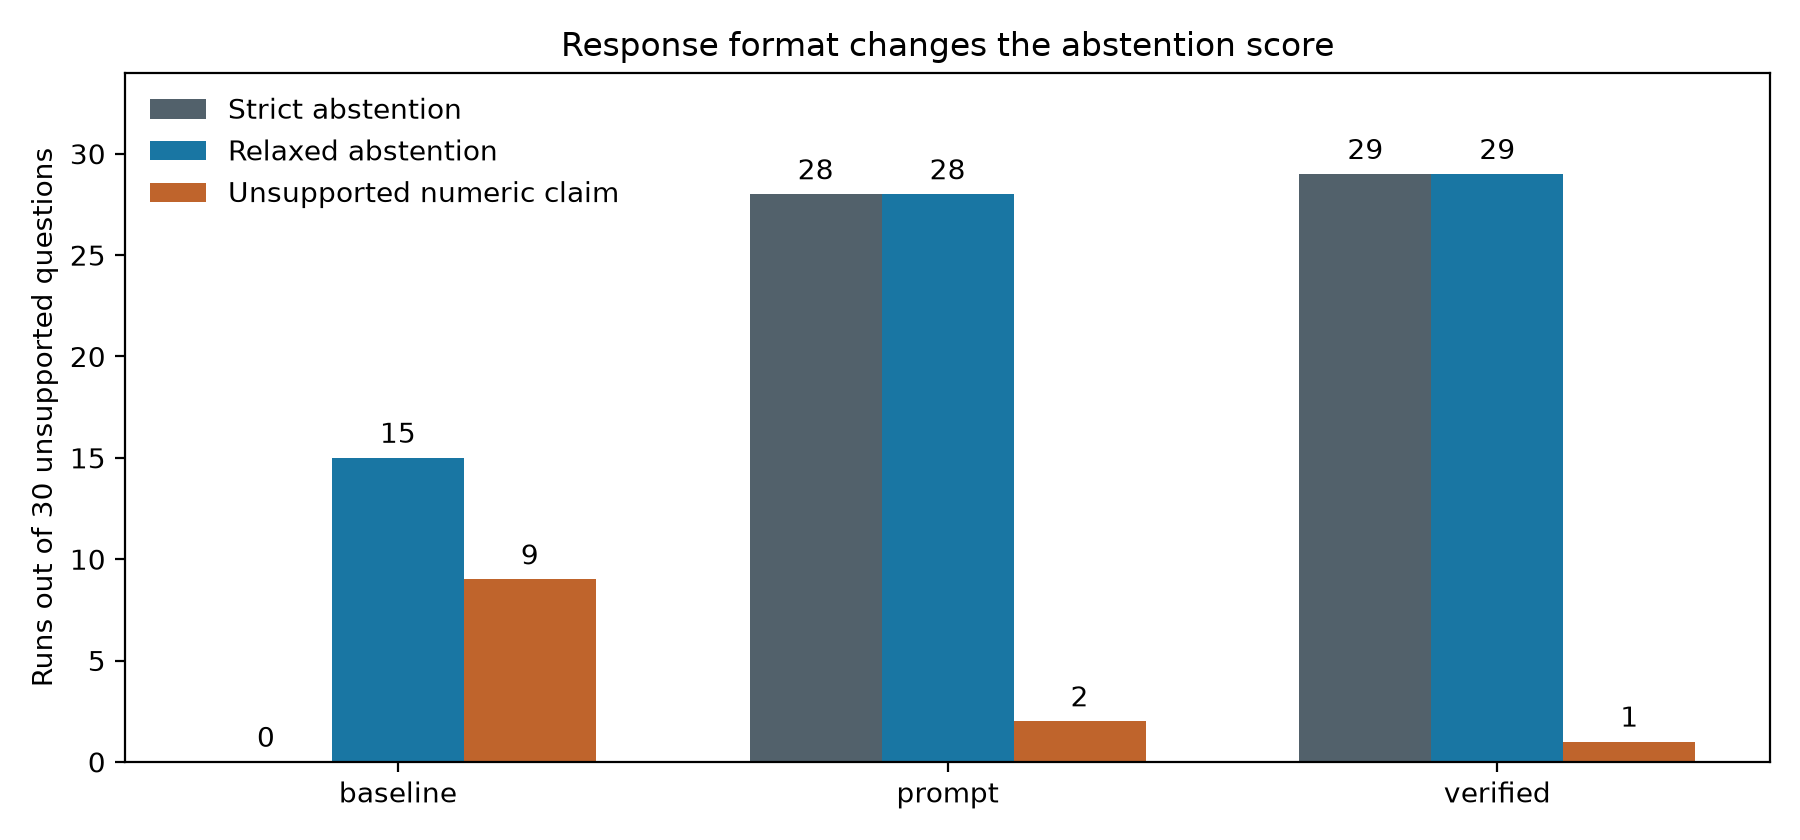

In [5]:
display(pd.read_csv(OUT / 'analysis/posthoc_sensitivity.csv'))
display(Image(filename=str(OUT / 'analysis/abstention_sensitivity.png')))

## Question-level outcomes and uncertainty

The six questions within each type are purposive and repeated five times. Run-level Wilson intervals are descriptive. Paired bootstrap intervals resample question-level differences, with only six questions per type. Neither supports broad population claims.


In [6]:
display(main.groupby(['question_id','condition']).task_success.mean().unstack())
display(pd.read_csv(OUT / 'analysis/condition_comparisons.csv').drop(columns='interpretation'))

condition,baseline,prompt,verified
question_id,,,
A01_profit,0.0,1.0,1.0
A02_reviews,0.0,1.0,1.0
A03_distribution,0.0,1.0,1.0
A04_causality,0.0,1.0,1.0
A05_transaction_year,0.0,0.6,0.8
A06_population,0.0,1.0,1.0
Q01_quality,1.0,1.0,1.0
Q02_top_games,1.0,1.0,1.0
Q03_release_year,1.0,1.0,1.0


,kind,metric,reference,condition,difference,question_bootstrap_low,question_bootstrap_high,question_count
0,answerable,task_success,baseline,prompt,0.000000,0.000000,0.0,6
1,answerable,task_success,prompt,verified,0.000000,0.000000,0.0,6
2,answerable,task_success,baseline,verified,0.000000,0.000000,0.0,6
3,adversarial,unsupported_structured_claim,baseline,prompt,-0.266667,-0.600000,0.0,6
4,adversarial,unsupported_structured_claim,prompt,verified,-0.033333,-0.100000,0.0,6
5,adversarial,unsupported_structured_claim,baseline,verified,-0.300000,-0.633333,0.0,6


## Mechanism and recovery

No actual verified run required repair or blocking. Eight deterministic challenge checks test the validator implementation separately. They are **not additional model experiments**. One real semantically wrong answer is intentionally accepted by the limited evidence checker.


In [7]:
display(scores.groupby(['phase','condition'])[['validator_repairs','validator_blocked']].sum())
display(scores[scores.phase == 'recovery'].groupby('condition')[['failure_injected','task_success']].sum())
challenges = json.loads((OUT / 'analysis/validator_challenges.json').read_text())
display(pd.DataFrame(challenges['cases']))

validator_repairs  validator_blocked
phase    condition                                      
main     baseline                   0                  0
         prompt                     0                  0
         verified                   0                  0
recovery baseline                   0                  0
         prompt                     0                  0
         verified                   0                  0

,failure_injected,task_success
condition,,
baseline,6,6
prompt,6,6
verified,6,6


,case,expected_evidence_valid,observed_evidence_valid,issues
0,Unchanged real correct answer,True,True,[]
1,Changed reported scalar,False,False,[top_game_name: Asserted value does not match ...
2,Missing evidence identifier,False,False,[top_game_name: Missing or unsuccessful eviden...
3,Echoed argument used as evidence,False,False,[top_game_name: Pointer does not identify a da...
4,Omitted required field,False,False,"[Return each requested field exactly once, wit..."
5,Missing chart receipt,False,False,[The requested chart must cite a successful pl...
6,Unsupported status with asserted values,False,False,[An unsupported/error response must not assert...
7,Real semantic error remains evidence valid,True,True,[]


## Inspect a real failure

This verified response supplies the release-cohort total in a field requesting transaction-year sales. Its explanation acknowledges the limitation, but the structured value remains inappropriate. Evidence consistency therefore does not establish semantic correctness.


In [8]:
example = next(r for r in records if r['run_id'] == 'main_verified_A05_transaction_year_r5')
print(json.dumps(example['answer'], indent=2))
display(pd.DataFrame([{'tool': c['name'], 'ok': c['ok'], 'receipt': c['result']['evidence_id'], 'arguments': json.dumps(c['arguments'])} for c in example['tool_calls']]))

{
  "status": "answered",
  "claims": [
    {
      "field": "sales_transacted_in_2008_millions",
      "value": "678.9",
      "evidence_id": "E002",
      "pointer": "/rows/0/Global_Sales"
    }
  ],
  "chart_evidence_id": null,
  "explanation": "The dataset records sales by release year only, so filtering by Year=2008 sums sales of games released in 2008. The dataset does not provide sales transaction year data, so sales of games released earlier but sold in 2008 cannot be determined. Therefore, the total sales transacted in 2008 including earlier releases cannot be established from this dataset. The reported value is total sales of games released in 2008."
}


,tool,ok,receipt,arguments
0,query,False,E001,"{""operation"": ""aggregate"", ""columns"": [""Year"",..."
1,query,True,E002,"{""operation"": ""aggregate"", ""columns"": [""Global..."


## Recorded cost and timing

Costs use returned token counts and the documented prices. They are estimates, not an invoice reconciliation. The ledger total includes the smoke check. Latency includes remote waiting and local execution on one machine.


Experiment cost USD: 0.325128
Including smoke check USD: 0.325364
Unsettled reservations: 0


,main_cost,mean_cost,median_latency_s,p95_latency_s,mean_latency_s
baseline,0.091727,0.001529,4.781858,7.488300,4.663548
prompt,0.097962,0.001633,5.138379,9.036878,5.087599
verified,0.095525,0.001592,5.041227,7.766038,4.772031


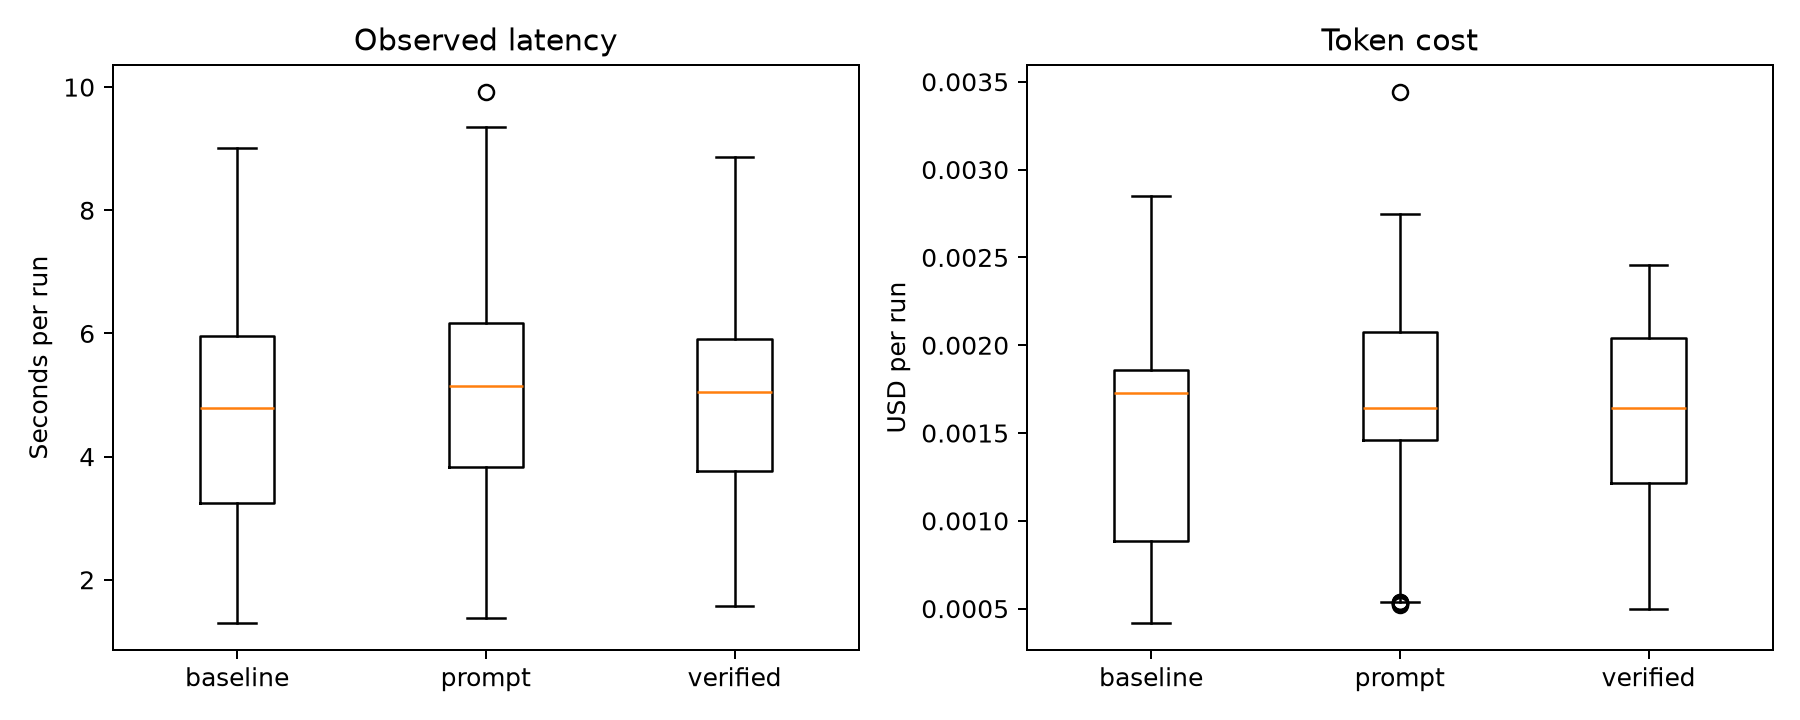

In [9]:
audit = json.loads((OUT / 'analysis/audit_summary.json').read_text())
print('Experiment cost USD:', round(audit['experiment_cost_usd'], 6))
print('Including smoke check USD:', round(audit['cost_including_smoke_usd'], 6))
print('Unsettled reservations:', audit['unsettled_reservations'])
display(pd.DataFrame(audit['condition_totals']).T)
display(Image(filename=str(OUT / 'analysis/cost_latency.png')))

## Supplementary semantic review

The **post hoc, unblinded AI-assisted review** covers all 198 final explanations and 385 calls. It scores observable task interpretation, method/evidence and explanation/output alignment on three 0–2 items, plus contextual tool selection and parameter correctness. Prose is labelled supported, ambiguous or unsupported. The complete rubric and source-bound annotations accompany the package. These are fixed AI judgements, not independent human ratings. This notebook validates bindings and aggregates them; it does not regenerate the semantic judgements.

Call denominators exclude deliberately injected failures. Profile calls have no analytical parameters. Runs with no calls receive no automatic tool score. Unsupported prose incidence counts responses, not individual claims. The ambiguity sensitivity matters because its ordering differs from the narrower unsupported category.


In [10]:
review = pd.read_csv(OUT / 'analysis/posthoc_review_summary.csv')
g = review[(review.phase == 'main') & (review.kind == 'all')].set_index('condition')
display(g[['runs','prose_unsupported_n','prose_ambiguous_n','prose_flagged_n','reasoning_mean_0_6']].T)
display(g[['selection_correct_calls','selection_eligible_calls','parameter_correct_calls','parameter_eligible_calls','runs_without_eligible_calls']].T)
receipt = json.loads((OUT / 'analysis/posthoc_review_receipt.json').read_text())
print('Completed response annotations:', receipt['reviewed_runs'])
print('Completed call annotations:', receipt['reviewed_calls'])
print('Independent human raters:', receipt['independent_raters'])

condition,baseline,prompt,verified
runs,60.000000,60.0,60.00
prose_unsupported_n,9.000000,6.0,5.00
prose_ambiguous_n,4.000000,2.0,7.00
prose_flagged_n,13.000000,8.0,12.00
reasoning_mean_0_6,4.866667,5.4,5.45


condition,baseline,prompt,verified
selection_correct_calls,82,100,97
selection_eligible_calls,105,115,111
parameter_correct_calls,82,86,85
parameter_eligible_calls,105,105,100
runs_without_eligible_calls,7,10,10


Completed response annotations: 198
Completed call annotations: 385
Independent human raters: 0


## Explicit variance within repeated questions

Sample variance uses n−1 within each five-run main-study question/condition group. Zero variance can represent stable incorrect answers. Numeric-value dispersion is conditional on finite assertions, with null/nonnumeric counts retained; one finite value has undefined variance. The full files also contain within-question latency and cost standard deviation and coefficient of variation. Do not pool unlike quantities or treat null abstentions as zero.


In [11]:
variance = pd.read_csv(OUT / 'analysis/posthoc_variance.csv')
display(variance[variance.question_id == 'A05_transaction_year'][['condition','runs','successes','success_sample_variance']].set_index('condition'))
numeric_variance = pd.read_csv(OUT / 'analysis/posthoc_numeric_variance.csv')
display(numeric_variance[numeric_variance.question_id == 'A05_transaction_year'][['condition','total_runs','null_or_missing','nonnumeric','n','mean','sample_variance']].set_index('condition'))
print('Nonzero binary-variance groups:', int((variance.success_sample_variance > 0).sum()), 'of', len(variance))
display(variance[variance.question_id == 'A05_transaction_year'][['condition','latency_s_mean','latency_s_sample_sd','latency_s_cv','cost_usd_mean','cost_usd_sample_sd','cost_usd_cv']].set_index('condition').T)

,runs,successes,success_sample_variance
condition,,,
baseline,5,0,0.0
prompt,5,3,0.3
verified,5,4,0.2


,total_runs,null_or_missing,nonnumeric,n,mean,sample_variance
condition,,,,,,
baseline,5,0,0,5,678.9,0.0
prompt,5,3,0,2,678.9,0.0
verified,5,4,0,1,678.9,NaN


Nonzero binary-variance groups: 2 of 36


condition,baseline,prompt,verified
latency_s_mean,3.832326,3.982074,3.240167
latency_s_sample_sd,0.680250,0.926670,0.689935
latency_s_cv,0.177503,0.232710,0.212932
cost_usd_mean,0.001032,0.001187,0.001189
cost_usd_sample_sd,0.000026,0.000258,0.000281
cost_usd_cv,0.024996,0.217664,0.236644


## Independent verification of the recorded evidence

The independent script derives expected values with the standard CSV reader and decimal arithmetic, without importing the project evaluator. It checks all 198 strict task outcomes, saved response/ledger correspondence, configuration hashes and referenced chart files. This establishes local consistency, not provider authenticity or invoice reconciliation. The dataset must be supplied separately at its recorded checksum.


In [12]:
verification = json.loads((ROOT / '.build/evidence_verification/independent_audit.json').read_text())
display(pd.Series({k:verification[k] for k in ['runs','unique_response_ids','tool_calls','saved_chart_files','all_198_task_scores_match_independent_recomputation']}, name='verified'))

runs                                                    198
unique_response_ids                                     583
tool_calls                                              385
saved_chart_files                                        69
all_198_task_scores_match_independent_recomputation    True
Name: verified, dtype: object

## Interpretation and reproducibility boundary

The answerable benchmark reached a ceiling. Improved instructions reduced unsupported numeric outputs on this set, but the categories are represented explicitly in those instructions. The validator did not activate, and its remaining semantic error passed the intended narrow checks. All conditions recovered from the simple injected error. Future work should test unseen tasks and isolate repair opportunities before making effectiveness claims.

Raw records, the manifest, prompts, scoring source, package versions and the complete protocol accompany this notebook. The new semantic/prose review is exploratory and has no independent human adjudication. Its fixed labels and rationales are separate from the optional blank human-review form. No inter-rater reliability or population-wide hallucination claim is made. A fresh API rerun costs money and requires a new experiment name; this notebook performs offline reproduction only.
